# Layer 6 — Graph Intelligence & Congestion Scoring
**Bengaluru Traffic Intelligence Platform (BTIP)**

Validates `backend/decision/graph_intelligence.py` and
`backend/decision/congestion_scorer.py`. Covers:

1. Betweenness / closeness centrality distribution
2. Top-20 structurally critical junctions vs top-20 by raw violations
3. Congestion Impact Score (0-100) summary
4. Choropleth / scatter of centrality + congestion across Bengaluru

**Prerequisite:** `GraphIntelligence().build()` and `CongestionScorer().compute()`
must have already been run, so `junction_centrality.parquet` and
`junction_congestion_scores.parquet` exist under `data/processed/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "backend").exists() is False else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from backend.decision.graph_intelligence import GraphIntelligence
from backend.decision.congestion_scorer import CongestionScorer

plt.rcParams["figure.facecolor"] = "#0B0E14"
plt.rcParams["axes.facecolor"] = "#141820"
plt.rcParams["axes.edgecolor"] = "#666B7A"
plt.rcParams["axes.labelcolor"] = "#E8E8E8"
plt.rcParams["text.color"] = "#E8E8E8"
plt.rcParams["xtick.color"] = "#E8E8E8"
plt.rcParams["ytick.color"] = "#E8E8E8"
plt.rcParams["figure.figsize"] = (8, 5)

CYAN, AMBER, RED, GREEN = "#00D4FF", "#FFB020", "#FF4444", "#00A86B"

## 1. Load centrality + congestion score caches

In [2]:
gi = GraphIntelligence()
centrality_df = gi.build(force_recompute=False)
print(f"Centrality: {centrality_df.height:,} nodes")
centrality_df.describe()

KeyboardInterrupt: 

In [ ]:
cs = CongestionScorer()
congestion_df = cs.compute()
print(f"Congestion scores: {congestion_df.height:,} junctions")
congestion_df.describe()

## 2. Betweenness / closeness centrality distribution

NameError: name 'centrality_df' is not defined

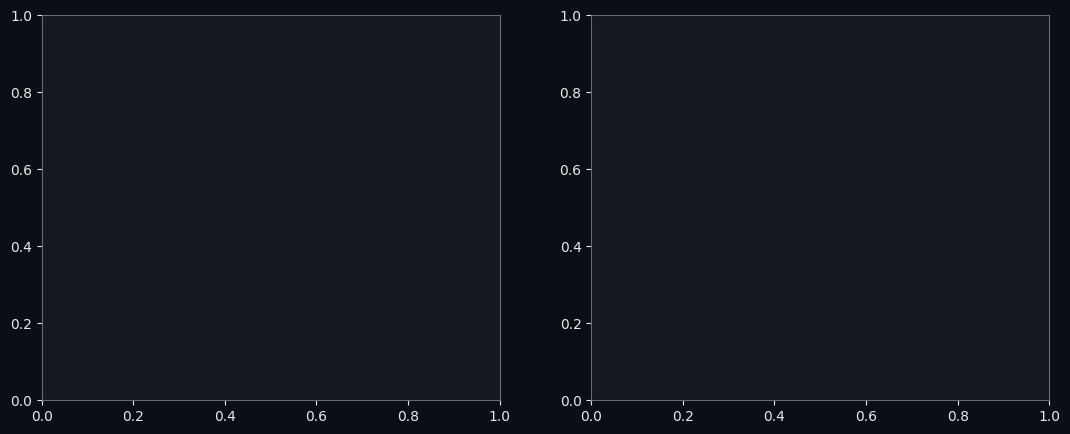

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(centrality_df["betweenness_norm"].to_numpy(), bins=50, color=CYAN, alpha=0.85)
axes[0].set_title("Betweenness Centrality (normalised)")
axes[0].set_xlabel("betweenness_norm")
axes[0].set_ylabel("node count")

axes[1].hist(centrality_df["closeness_norm"].to_numpy(), bins=50, color=AMBER, alpha=0.85)
axes[1].set_title("Closeness Centrality (normalised)")
axes[1].set_xlabel("closeness_norm")

plt.tight_layout()
plt.show()

print(f"Betweenness — mean: {centrality_df['betweenness_norm'].mean():.4f}, "
      f"p95: {centrality_df['betweenness_norm'].quantile(0.95):.4f}")
print(f"Closeness   — mean: {centrality_df['closeness_norm'].mean():.4f}, "
      f"p95: {centrality_df['closeness_norm'].quantile(0.95):.4f}")

## 3. Top-20 structurally critical junctions vs Top-20 by raw violation count

The whole point of graph intelligence: prove that some junctions matter
*structurally* (high betweenness — lots of traffic routes through them) even
though they don't top the raw violation-count leaderboard. Those are the
junctions where enforcement has outsized city-wide impact.

In [ ]:
top20_centrality = congestion_df.sort("betweenness_norm", descending=True).head(20)
top20_violations = congestion_df.sort("total_violations", descending=True).head(20)

centrality_ids = set(top20_centrality["junction_id"].to_list())
violation_ids = set(top20_violations["junction_id"].to_list())

only_structural = centrality_ids - violation_ids
only_raw = violation_ids - centrality_ids
overlap = centrality_ids & violation_ids

print(f"Overlap: {len(overlap)} junctions in both top-20 lists")
print(f"Structurally critical but NOT in raw top-20: {len(only_structural)} junctions")
print(f"  -> {sorted(only_structural)}")
print(f"High raw violations but NOT structurally critical: {len(only_raw)} junctions")
print(f"  -> {sorted(only_raw)}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    congestion_df["total_violations"].to_numpy(),
    congestion_df["betweenness_norm"].to_numpy(),
    c=congestion_df["congestion_score"].to_numpy(),
    cmap="plasma",
    s=40,
    alpha=0.8,
)
ax.set_xlabel("Raw violation count")
ax.set_ylabel("Betweenness centrality (normalised)")
ax.set_title("Raw violations vs structural importance\n(color = congestion_score)")
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("congestion_score (0-100)")
plt.tight_layout()
plt.show()

## 4. Congestion Impact Score — distribution and top junctions

In [ ]:
fig, ax = plt.subplots()
ax.hist(congestion_df["congestion_score"].to_numpy(), bins=40, color=GREEN, alpha=0.85)
ax.axvline(33, color=GREEN, linestyle="--", linewidth=1, label="Low/Med boundary")
ax.axvline(67, color=RED, linestyle="--", linewidth=1, label="Med/High boundary")
ax.set_xlabel("congestion_score (0-100)")
ax.set_ylabel("junction count")
ax.set_title("Congestion Impact Score Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print("Top-10 by congestion_score:")
congestion_df.sort("congestion_score", descending=True).head(10).select(
    ["junction_id", "congestion_score", "total_violations", "betweenness_norm"]
)

## 5. Geo scatter — city-wide congestion choropleth

Static matplotlib scatter standing in for the Deck.gl choropleth used in
the frontend (`/hotspots` HexagonLayer, Layer 11). Marker size = total
violations, color = congestion_score.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 9))
sc = ax.scatter(
    congestion_df["lng"].to_numpy(),
    congestion_df["lat"].to_numpy(),
    c=congestion_df["congestion_score"].to_numpy(),
    s=np.clip(congestion_df["total_violations"].to_numpy() / 5, 10, 300),
    cmap="plasma",
    alpha=0.8,
    edgecolors="none",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bengaluru — Junction Congestion Impact Score\n(size = violation count, color = congestion_score)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("congestion_score (0-100)")
plt.tight_layout()
plt.show()

## Summary

- **Centrality distribution** — confirms betweenness/closeness are right-skewed
  (most junctions are peripheral; a small set are structurally critical hubs).
- **Top-20 comparison** — quantifies how many high-betweenness junctions would
  be *missed* by a naive "patrol where violations happened most" strategy.
  This is the core justification for graph-aware patrol allocation in Layer 7.
- **Congestion score distribution** — sanity-checks the 0-100 scaling and the
  Low(<33)/Medium/High(>67) thresholds used consistently across the platform.
- **Geo scatter** — visual sanity check that high-congestion junctions cluster
  around known arterial corridors rather than being randomly scattered (a
  random scatter would indicate a bug in the centrality join).